In [1]:
from hdfs import InsecureClient

In [24]:
!hostname -I

172.21.0.7 


In [25]:
# 경로내 목록 읽어오기
user = 'hadoop'
host = 'http://namenode:9870'
hdfs_path = '/dataset'
hdfs = InsecureClient(host,user)

show = hdfs.list(hdfs_path)
for s in show:
    print(s)

부산광역시방범용CCTV정보.csv
부산광역시방범용CCTV정보202512.csv
인천공항이용자수20260605.csv
인천공항이용자수20260605_lite.csv
주민등록인구및세대현황.csv
행정구역시도성연령별취업자20260609.csv
hdfs월분기연간인구동향출생202606.csv
py13_데이터분석_인터넷모바일쇼핑몰매출(완).ipynb


In [3]:
import pandas as pd

# CSV 파일 읽기
file_path = './dataset/부산광역시방범용CCTV정보202512.csv'
df = pd.read_csv(file_path, encoding='cp949')
print(df.head())

   연번  구군  장비종류                 관리번호                            시설명칭  \
0   1  중구  생활방범  3250000-00001-0-1HA      0001-1-영주1동-영주1동주민센터_옆_사거리   
1   2  중구  생활방범  3250000-00001-1-2HA  중구-0045_영주1동-영주1동주민센터_옆_사거리_고1   
2   3  중구  생활방범  3250000-00001-2-2HA  중구-0045_영주1동-영주1동주민센터_옆_사거리_고2   
3   4  중구  생활방범  3250000-00001-3-2HA  중구-0045_영주1동-영주1동주민센터_옆_사거리_고3   
4   5  중구  생활방범  3250000-00001-4-2HA  중구-0045_영주1동-영주1동주민센터_옆_사거리_고4   

          위도          경도  
0  35.110905  129.035121  
1  35.110905  129.035121  
2  35.110905  129.035121  
3  35.110905  129.035121  
4  35.110905  129.035121  


In [4]:
# 경로내 파일 읽어오기
user = 'hadoop'
host = 'http://namenode:9870'
hdfs_path = '/dataset'
hdfs = InsecureClient(host,user)

show = hdfs.list(hdfs_path)
for s in show:
    print(s)

부산광역시방범용CCTV정보.csv
부산광역시방범용CCTV정보202512.csv
인천공항이용자수20260605.csv
인천공항이용자수20260605_lite.csv
주민등록인구및세대현황.csv
행정구역시도성연령별취업자20260609.csv
hdfs월분기연간인구동향출생202606.csv
py13_데이터분석_인터넷모바일쇼핑몰매출(완).ipynb


In [5]:
# 파일의 전체 경로를 지정합니다.
file_path = "/dataset/부산광역시방범용CCTV정보202512.csv"

# hdfs.read()에 전체 경로를 전달합니다.
with hdfs.read(file_path, encoding='cp949') as reader:
    text = reader.read()

print(text[:100])

연번,구군,장비종류,관리번호,시설명칭,위도,경도
1,중구,생활방범,3250000-00001-0-1HA,0001-1-영주1동-영주1동주민센터_옆_사거리,35.110905,129.0


In [6]:
# 워드카운트
from collections import Counter

word = text[:5000].strip().split(',')
word_counts = Counter(word)
for word, count in word_counts.items():
    print(word,count)

연번 1
구군 1
장비종류 1
관리번호 1
시설명칭 1
위도 1
경도
1 1
중구 63
생활방범 63
3250000-00001-0-1HA 1
0001-1-영주1동-영주1동주민센터_옆_사거리 1
35.110905 5
129.035121
2 1
3250000-00001-1-2HA 1
중구-0045_영주1동-영주1동주민센터_옆_사거리_고1 1
129.035121
3 1
3250000-00001-2-2HA 1
중구-0045_영주1동-영주1동주민센터_옆_사거리_고2 1
129.035121
4 1
3250000-00001-3-2HA 1
중구-0045_영주1동-영주1동주민센터_옆_사거리_고3 1
129.035121
5 1
3250000-00001-4-2HA 1
중구-0045_영주1동-영주1동주민센터_옆_사거리_고4 1
129.035121
6 1
3250000-00002-0-1DA 1
0002-1-보수동-숲속어린이집_옆_쉼터 1
35.103814 4
129.027592
7 1
3250000-00002-1-1DA 1
0002-1-보수동-숲속어린이집_옆_쉼터_고1 1
129.027592
8 1
3250000-00002-2-1DA 1
0002-1-보수동-숲속어린이집_옆_쉼터_고2 1
129.027592
9 1
3250000-00002-3-1DA 1
0002-1-보수동-숲속어린이집_옆_쉼터_고3 1
129.027592
10 1
3250000-00003-0-1IA 1
0003-1-영주2동-중구노인복지관분관_옆_오거리 1
35.109886 4
129.032387
11 1
3250000-00003-1-2IA 1
중구-0149-영주2동-중구노인복지분관_옆_오거리_고1 1
129.032387
12 1
3250000-00003-2-2IA 1
중구-0149-영주2동-중구노인복지분관_옆_오거리_고2 1
129.032387
13 1
3250000-00003-3-2IA 1
중구-0149-영주2동-중구노인복지분관_옆_오거리_고3 1
129.032387
14 1
3250000-00004-0-1IA 1


In [7]:
# 파일업로드
local_file = './dataset/청소년정신건강20260604.csv'
hdfs_file = './dataset/hdfs청소년정신건강20260604.csv'
hdfs.upload(hdfs_file, local_file, overwrite = True)
print("업로드완료")

업로드완료


In [8]:
# 파일확인
hdfs_file = './dataset/hdfs청소년정신건강20260604.csv'
if hdfs.status(hdfs_file, strict=False)==None:
    print(f"{hdfs_file[9:]} 파일이 없습니다.")
else:
    print(hdfs.status(hdfs_file, strict=False))

{'accessTime': 1781230060520, 'blockSize': 134217728, 'childrenNum': 0, 'fileId': 16405, 'group': 'supergroup', 'length': 333, 'modificationTime': 1781230060573, 'owner': 'hadoop', 'pathSuffix': '', 'permission': '644', 'replication': 2, 'storagePolicy': 0, 'type': 'FILE'}


In [9]:
# 파일삭제
hdfs_file = './dataset/hdfs청소년정신건강20260604.csv'
if hdfs.status(hdfs_file, strict=False)==None:
    print(f"{hdfs_file[9:]} 파일이 없습니다.")
else:
    if hdfs.delete(hdfs_file):
        print("삭제되었습니다.")

삭제되었습니다.


---
## 전체 코드 정리 (HDFS CRUD 요약)

| 기능 | 메서드 | 설명 |
|------|--------|------|
| 목록 조회 | `hdfs.list(path)` | 경로 내 파일/폴더 목록 반환 |
| 파일 읽기 | `hdfs.read(path, encoding)` | 파일 내용을 스트림으로 읽기 |
| 파일 업로드 | `hdfs.upload(hdfs_path, local_path, overwrite)` | 로컬 파일을 HDFS에 업로드 |
| 파일 존재 확인 | `hdfs.status(path, strict=False)` | 파일 메타정보 반환 (없으면 None) |
| 파일 삭제 | `hdfs.delete(path)` | HDFS 파일 삭제 |

In [10]:
# ===== HDFS CRUD 전체 정리 코드 =====
from hdfs import InsecureClient

# 클라이언트 연결
user = 'hadoop'
host = 'http://namenode:9870'
hdfs_path = '/dataset'
hdfs = InsecureClient(host, user=user)

# 1. 목록 조회 (Read - List)
print("=" * 40)
print("[1] HDFS 디렉토리 목록 조회")
file_list = hdfs.list(hdfs_path)
for f in file_list:
    print(f"  - {f}")

[1] HDFS 디렉토리 목록 조회
  - 부산광역시방범용CCTV정보.csv
  - 부산광역시방범용CCTV정보202512.csv
  - 인천공항이용자수20260605.csv
  - 인천공항이용자수20260605_lite.csv
  - 주민등록인구및세대현황.csv
  - 행정구역시도성연령별취업자20260609.csv
  - hdfs월분기연간인구동향출생202606.csv
  - py13_데이터분석_인터넷모바일쇼핑몰매출(완).ipynb


In [11]:

# 2. 파일 읽기 (Read)
print("\n[2] 파일 읽기")
file_name = hdfs_path + "/부산광역시방범용CCTV정보202512.csv"
with hdfs.read(file_name, encoding='cp949') as reader:
    text = reader.read()
print(f"  파일 크기: {len(text)} 글자")
print(f"  첫 100자: {text[:100]}")



[2] 파일 읽기
  파일 크기: 1762049 글자
  첫 100자: 연번,구군,장비종류,관리번호,시설명칭,위도,경도
1,중구,생활방범,3250000-00001-0-1HA,0001-1-영주1동-영주1동주민센터_옆_사거리,35.110905,129.0


In [12]:

# 3. 파일 업로드 (Create)
print("\n[3] 파일 업로드")
local_file = './dataset/청소년정신건강20260604.csv'
hdfs_file = '/dataset/hdfs청소년정신건강20260604.csv'
hdfs.upload(hdfs_file, local_file, overwrite=True)
print(f"  업로드 완료: {hdfs_file}")



[3] 파일 업로드
  업로드 완료: /dataset/hdfs청소년정신건강20260604.csv


In [13]:

# 4. 파일 존재 확인 (Read - Status)
print("\n[4] 파일 존재 확인")
status = hdfs.status(hdfs_file, strict=False)
if status is None:
    print(f"  {hdfs_file[9:]} 파일이 없습니다.")
else:
    print(f"  파일 존재 확인! 크기: {status['length']} bytes")



[4] 파일 존재 확인
  파일 존재 확인! 크기: 333 bytes


In [14]:

# 5. 파일 삭제 (Delete)
print("\n[5] 파일 삭제")
status = hdfs.status(hdfs_file, strict=False)
if status is None:
    print(f"  {hdfs_file[9:]} 파일이 없습니다.")
else:
    hdfs.delete(hdfs_file)
    print(f"  {hdfs_file[9:]} 삭제 완료!")
print("=" * 40)


[5] 파일 삭제
  hdfs청소년정신건강20260604.csv 삭제 완료!


---
## 연습용 개선 코드

아래 코드는 다음 기능을 추가로 연습합니다:
- **HdfsManager 클래스**로 CRUD 기능 캡슐화
- **pandas DataFrame** 연동으로 CSV 데이터 분석
- **디렉토리 생성/삭제** (mkdir, delete recursive)
- **파일 이름 변경** (rename)
- **파일 목록 상세 정보** (status per file)
- **텍스트 파일 쓰기** (write)

In [15]:
# ===== 연습용 개선 코드: HdfsManager 클래스 =====
from hdfs import InsecureClient
import pandas as pd
import io

class HdfsManager:
    """HDFS CRUD 작업을 캡슐화한 매니저 클래스"""

    def __init__(self, host='http://namenode:9870', user='hadoop'):
        self.hdfs = InsecureClient(host, user=user)
        print(f"HDFS 연결: {host} (user={user})")

    # --- 조회 기능 ---
    def list_dir(self, path, detail=False):
        """디렉토리 목록 조회 (detail=True면 크기/날짜 포함)"""
        files = self.hdfs.list(path, status=detail)
        if detail:
            print(f"{'파일명':<40} {'크기(bytes)':>12} {'타입'}")
            print("-" * 60)
            for name, info in files:
                print(f"{name:<40} {info['length']:>12} {info['type']}")
        else:
            for f in files:
                print(f"  - {f}")
        return files

    def exists(self, path):
        """파일/디렉토리 존재 여부 확인"""
        return self.hdfs.status(path, strict=False) is not None

    # --- 읽기 기능 ---
    def read_csv(self, hdfs_path, encoding='cp949'):
        """HDFS CSV 파일을 pandas DataFrame으로 읽기"""
        with self.hdfs.read(hdfs_path, encoding=encoding) as reader:
            text = reader.read()
        df = pd.read_csv(io.StringIO(text))
        print(f"  로드 완료: {df.shape[0]}행 x {df.shape[1]}열")
        return df

    def read_text(self, hdfs_path, encoding='utf-8', preview=200):
        """텍스트 파일 미리보기"""
        with self.hdfs.read(hdfs_path, encoding=encoding) as reader:
            text = reader.read()
        print(f"  전체 크기: {len(text)} 글자")
        print(f"  미리보기:\n{text[:preview]}")
        return text

    # --- 쓰기 기능 ---
    def write_text(self, hdfs_path, content, encoding='utf-8', overwrite=True):
        """텍스트 내용을 HDFS 파일로 직접 쓰기"""
        data = content.encode(encoding)
        with self.hdfs.write(hdfs_path, overwrite=overwrite) as writer:
            writer.write(data)
        print(f"  쓰기 완료: {hdfs_path} ({len(data)} bytes)")

    def upload(self, local_path, hdfs_path, overwrite=True):
        """로컬 파일을 HDFS에 업로드"""
        if not self.exists(hdfs_path) or overwrite:
            self.hdfs.upload(hdfs_path, local_path, overwrite=overwrite)
            print(f"  업로드 완료: {local_path} → {hdfs_path}")
        else:
            print(f"  이미 존재합니다 (overwrite=False): {hdfs_path}")

    # --- 관리 기능 ---
    def mkdir(self, path):
        """HDFS 디렉토리 생성"""
        self.hdfs.makedirs(path)
        print(f"  디렉토리 생성: {path}")

    def rename(self, src, dst):
        """파일/디렉토리 이름 변경"""
        self.hdfs.rename(src, dst)
        print(f"  이름 변경: {src} → {dst}")

    def delete(self, path, recursive=False):
        """파일 또는 디렉토리 삭제"""
        if not self.exists(path):
            print(f"  없는 경로: {path}")
            return
        self.hdfs.delete(path, recursive=recursive)
        print(f"  삭제 완료: {path}")


# ===== 사용 예시 =====
mgr = HdfsManager()
print()

# 1. 상세 목록 조회
print("[1] /dataset 상세 목록")
mgr.list_dir('/dataset', detail=True)
print()

HDFS 연결: http://namenode:9870 (user=hadoop)

[1] /dataset 상세 목록
파일명                                         크기(bytes) 타입
------------------------------------------------------------
부산광역시방범용CCTV정보.csv                             107537 FILE
부산광역시방범용CCTV정보202512.csv                      2179418 FILE
인천공항이용자수20260605.csv                             9613 FILE
인천공항이용자수20260605_lite.csv                        5026 FILE
주민등록인구및세대현황.csv                                  2056 FILE
행정구역시도성연령별취업자20260609.csv                      345271 FILE
hdfs월분기연간인구동향출생202606.csv                       14823 FILE
py13_데이터분석_인터넷모바일쇼핑몰매출(완).ipynb                137311 FILE



In [16]:
# 2. CSV → DataFrame 분석
print("[2] CSV 파일을 DataFrame으로 읽기 & 분석")
df = mgr.read_csv('/dataset/부산광역시방범용CCTV정보202512.csv', encoding='cp949')
print(df.head(3))
print(f"\n  컬럼: {list(df.columns)}")
print(f"  구군별 CCTV 수:\n{df['구군'].value_counts().head(5)}")
print()

[2] CSV 파일을 DataFrame으로 읽기 & 분석
  로드 완료: 21060행 x 7열
   연번  구군  장비종류                 관리번호                            시설명칭  \
0   1  중구  생활방범  3250000-00001-0-1HA      0001-1-영주1동-영주1동주민센터_옆_사거리   
1   2  중구  생활방범  3250000-00001-1-2HA  중구-0045_영주1동-영주1동주민센터_옆_사거리_고1   
2   3  중구  생활방범  3250000-00001-2-2HA  중구-0045_영주1동-영주1동주민센터_옆_사거리_고2   

          위도          경도  
0  35.110905  129.035121  
1  35.110905  129.035121  
2  35.110905  129.035121  

  컬럼: ['연번', '구군', '장비종류', '관리번호', '시설명칭', '위도', '경도']
  구군별 CCTV 수:
구군
남구      2032
사하구     1823
북구      1714
해운대구    1683
강서구     1668
Name: count, dtype: int64



In [17]:
# 결측값 카운트
print("결측값 개수 (컬럼별):")
print(df.isnull().sum())
print(f"\n전체 결측값: {df.isnull().sum().sum()}개")
print(f"결측값 있는 컬럼: {df.isnull().any().sum()}개")

결측값 개수 (컬럼별):
연번      0
구군      0
장비종류    0
관리번호    0
시설명칭    0
위도      0
경도      0
dtype: int64

전체 결측값: 0개
결측값 있는 컬럼: 0개


In [18]:
# 3. 텍스트 직접 쓰기 → 이름 변경 → 삭제
print("[3] 텍스트 파일 쓰기")
mgr.write_text('/dataset/test_write.txt', "HDFS 쓰기 연습\nHello, HDFS!\n테스트 완료", encoding='utf-8')

print("\n[4] 파일 존재 확인")
print(f"  test_write.txt 존재: {mgr.exists('/dataset/test_write.txt')}")

print("\n[5] 파일 이름 변경")
mgr.rename('/dataset/test_write.txt', '/dataset/test_renamed.txt')

print("\n[6] 이름 변경 후 목록 확인")
mgr.list_dir('/dataset')

print("\n[7] 임시 파일 삭제")
mgr.delete('/dataset/test_renamed.txt')

print("\n[8] 삭제 후 목록 확인")
mgr.list_dir('/dataset')

[3] 텍스트 파일 쓰기
  쓰기 완료: /dataset/test_write.txt (48 bytes)

[4] 파일 존재 확인
  test_write.txt 존재: True

[5] 파일 이름 변경
  이름 변경: /dataset/test_write.txt → /dataset/test_renamed.txt

[6] 이름 변경 후 목록 확인
  - 부산광역시방범용CCTV정보.csv
  - 부산광역시방범용CCTV정보202512.csv
  - 인천공항이용자수20260605.csv
  - 인천공항이용자수20260605_lite.csv
  - 주민등록인구및세대현황.csv
  - 행정구역시도성연령별취업자20260609.csv
  - hdfs월분기연간인구동향출생202606.csv
  - py13_데이터분석_인터넷모바일쇼핑몰매출(완).ipynb
  - test_renamed.txt

[7] 임시 파일 삭제
  삭제 완료: /dataset/test_renamed.txt

[8] 삭제 후 목록 확인
  - 부산광역시방범용CCTV정보.csv
  - 부산광역시방범용CCTV정보202512.csv
  - 인천공항이용자수20260605.csv
  - 인천공항이용자수20260605_lite.csv
  - 주민등록인구및세대현황.csv
  - 행정구역시도성연령별취업자20260609.csv
  - hdfs월분기연간인구동향출생202606.csv
  - py13_데이터분석_인터넷모바일쇼핑몰매출(완).ipynb


['부산광역시방범용CCTV정보.csv',
 '부산광역시방범용CCTV정보202512.csv',
 '인천공항이용자수20260605.csv',
 '인천공항이용자수20260605_lite.csv',
 '주민등록인구및세대현황.csv',
 '행정구역시도성연령별취업자20260609.csv',
 'hdfs월분기연간인구동향출생202606.csv',
 'py13_데이터분석_인터넷모바일쇼핑몰매출(완).ipynb']

In [19]:
# 9. 디렉토리 생성 → 파일 업로드 → 디렉토리 전체 삭제
print("[9] 서브 디렉토리 생성 & 업로드 & 재귀 삭제")
mgr.mkdir('/dataset/temp_dir')
mgr.upload('./dataset/청소년정신건강20260604.csv', '/dataset/temp_dir/청소년정신건강.csv')

print("\n  temp_dir 내 목록:")
mgr.list_dir('/dataset/temp_dir')

print("\n  temp_dir 재귀 삭제")
mgr.delete('/dataset/temp_dir', recursive=True)
print(f"  temp_dir 존재: {mgr.exists('/dataset/temp_dir')}")

[9] 서브 디렉토리 생성 & 업로드 & 재귀 삭제
  디렉토리 생성: /dataset/temp_dir
  업로드 완료: ./dataset/청소년정신건강20260604.csv → /dataset/temp_dir/청소년정신건강.csv

  temp_dir 내 목록:
  - 청소년정신건강.csv

  temp_dir 재귀 삭제
  삭제 완료: /dataset/temp_dir
  temp_dir 존재: False


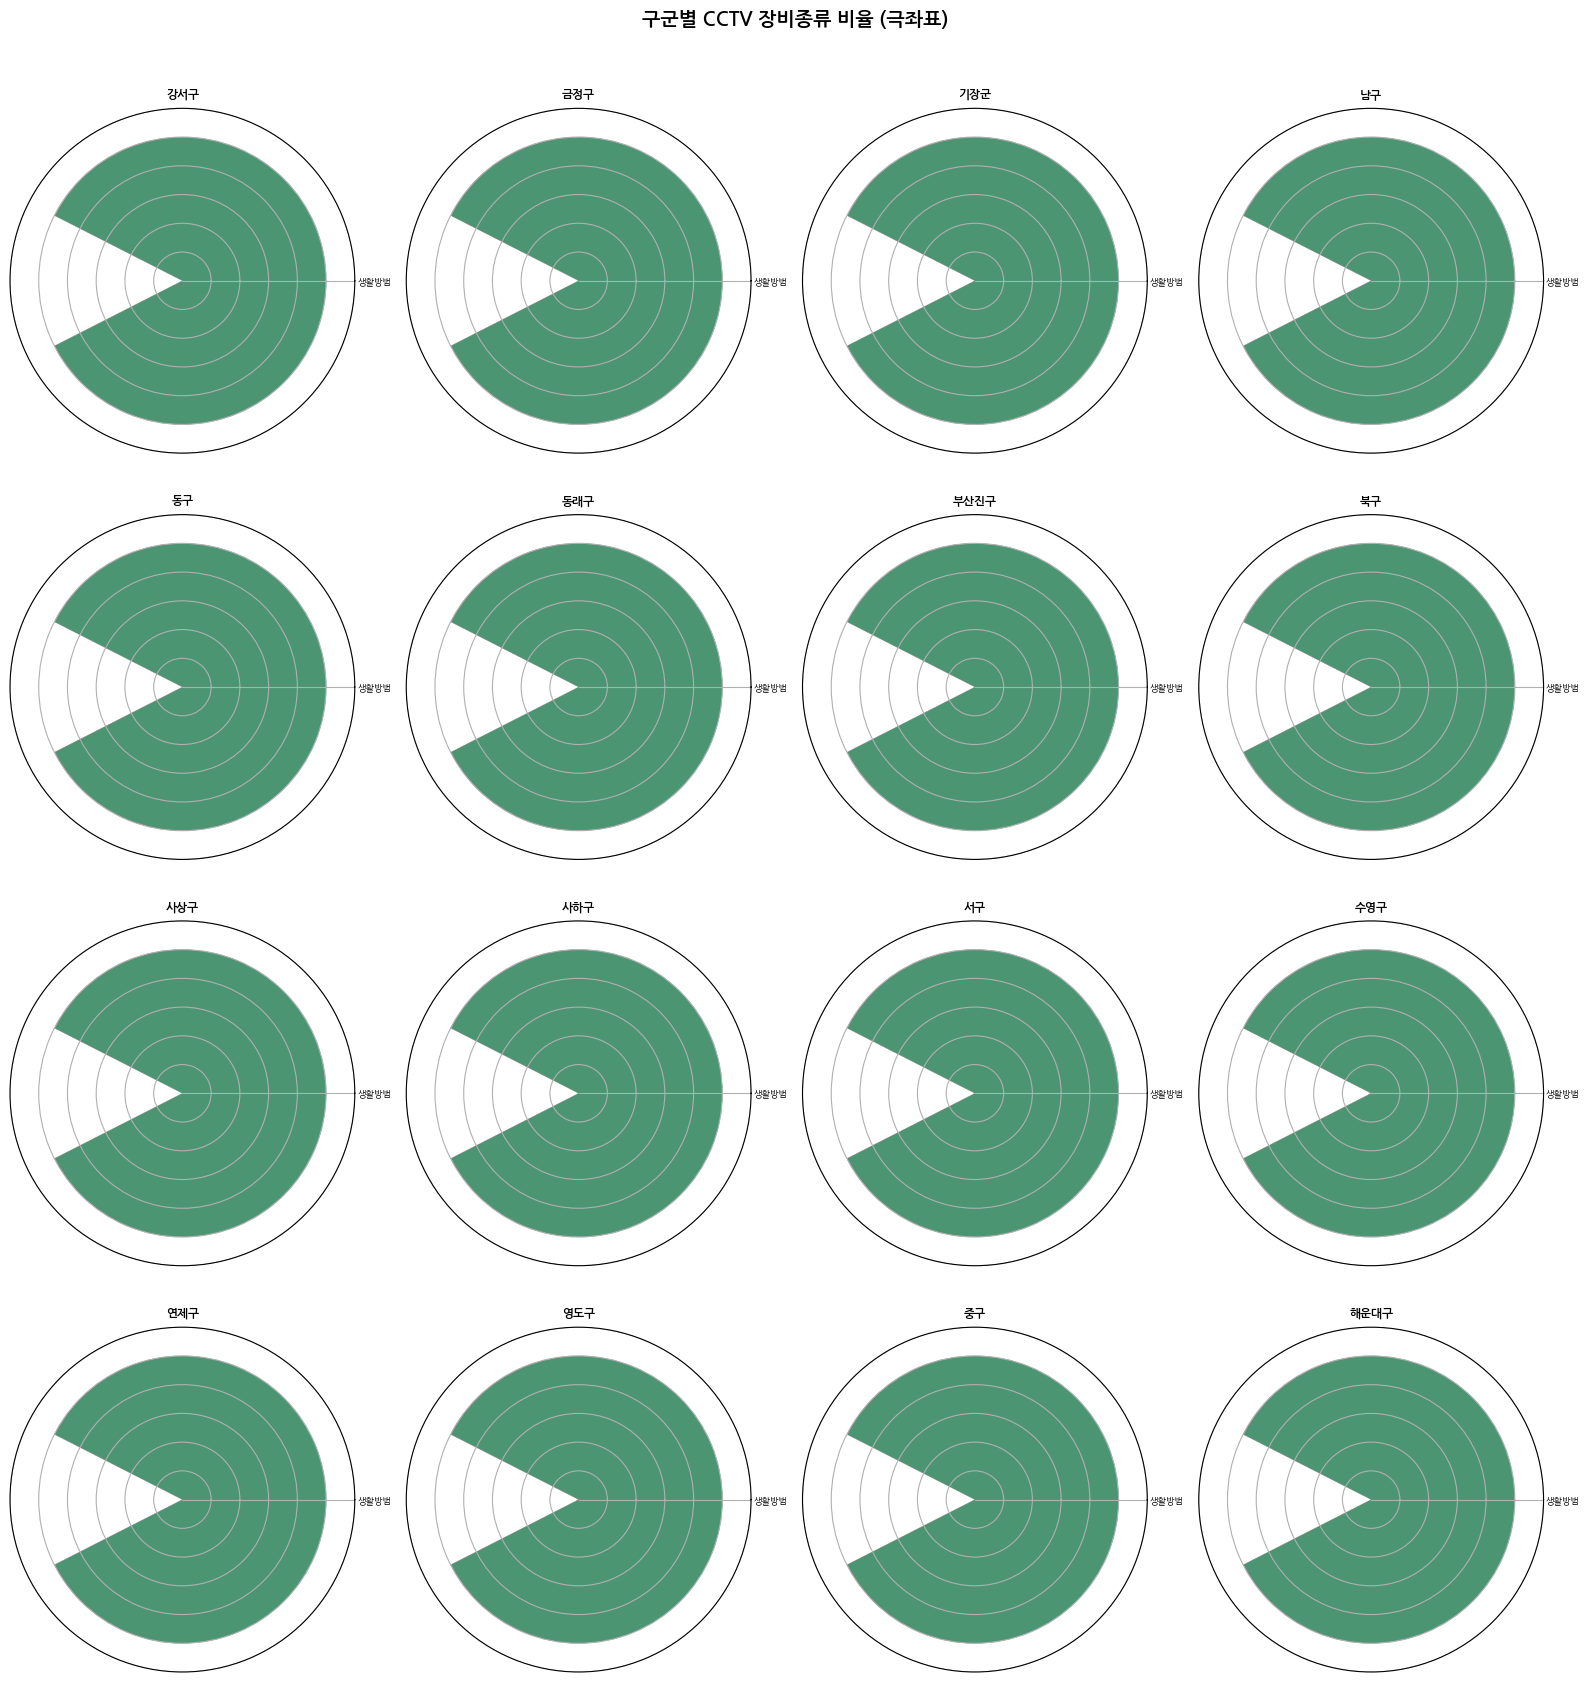

In [27]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 구군별 장비종류 비율 계산
counts = df.groupby(['구군', '장비종류']).size().reset_index(name='count')
counts['percent'] = counts.groupby('구군')['count'].transform(lambda x: 100 * x / x.sum())

locations = counts['구군'].unique()
n = len(locations)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4.2),
                         subplot_kw={'projection': 'polar'})
axes = axes.flatten()

for i, loc in enumerate(locations):
    ax = axes[i]
    sub = counts[counts['구군'] == loc]

    categories = sub['장비종류'].values
    percent = sub['percent'].values

    n_cat = len(categories)
    theta = np.linspace(0, 2 * np.pi, n_cat, endpoint=False)
    theta_closed = np.append(theta, theta[0])
    r_closed = np.append(percent, percent[0])

    colors = cm.RdYlGn(percent / percent.max())

    bar_width = 2 * np.pi / n_cat * 0.85
    ax.bar(theta, percent, width=bar_width, color=colors,
           alpha=0.7, linewidth=0.3, edgecolor='gray')
    ax.plot(theta_closed, r_closed, color='steelblue', linewidth=1.2, alpha=0.8)

    ax.set_xticks(theta)
    ax.set_xticklabels(categories, fontsize=6.5)
    ax.set_yticklabels([])
    ax.set_ylim(0, percent.max() * 1.2)

    ax.set_title(loc, fontsize=8.5, pad=8, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('구군별 CCTV 장비종류 비율 (극좌표)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
